In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier



df_desordenado = pd.read_csv('../data/fantasy_data.csv')
df_desordenado = df_desordenado.drop(["PPGTarget_half-ppr","PointsTarget_half-ppr"], axis=1)

In [23]:
# Asegúrate de ordenar por Jugador y Año
df_desordenado = df_desordenado.sort_values(by=['Key', 'Year'])

# 1. PUNTOS POR OPORTUNIDAD (Eficiencia)
# Sumamos 1 a Touches para evitar división por cero
df_desordenado['Efficiency'] = df_desordenado['Points_half-ppr'] / (df_desordenado['Touches'] + 1)

# 2. DELTAS (Cambio respecto al año anterior)
# groupby('Key') asegura que compares al jugador consigo mismo
df_desordenado['Delta_PPG'] = df_desordenado.groupby('Key')['PPG_half-ppr'].diff().fillna(0)
df_desordenado['Delta_Touches'] = df_desordenado.groupby('Key')['Touches'].diff().fillna(0)

# 3. LAGS (Dato de hace 2 años, por si el año pasado se lesionó)
df_desordenado['Lag_2_PPG'] = df_desordenado.groupby('Key')['PPG_half-ppr'].shift(2).fillna(0)

# 4. EDAD AL CUADRADO (Captura la curva de envejecimiento)
df_desordenado['Age_Sq'] = df_desordenado['Age'] ** 2

print("Variables nuevas agregadas.")

Variables nuevas agregadas.


In [24]:
df_ordenado = df_desordenado.sort_values('Year')
df_ordenado = df_ordenado[~df_ordenado['Year'].between(1970, 1999)]
df_ordenado

,Player,Tm,Pos,Age,G,GS,Pass_Cmp,Pass_Att,Pass_Yds,Pass_TD,...,PPGPosRank_half-ppr,PPTOvrRank_half-ppr,PPTPosRank_half-ppr,Points_VORP_half-ppr,PPG_VORP_half-ppr,Efficiency,Delta_PPG,Delta_Touches,Lag_2_PPG,Age_Sq
12838,Qadry Ismail,BAL,WR,30,15,13,0,0,0,0,...,42,55,41,-16.00,-1.443750,2.400000,-3.306250,-20.0,-0.200000,900
9035,Jeff Garcia,SFO,QB,30,16,16,355,561,4278,31,...,2,364,6,142.08,7.216250,0.549716,9.024038,213.0,0.000000,900
25833,Derrius Thompson,WAS,WR,23,4,0,0,0,0,0,...,164,470,164,-136.00,-9.443750,0.000000,0.000000,0.0,0.000000,529
23353,Mike Sellers,WAS,TE,25,15,6,0,0,0,0,...,47,38,10,-52.90,-3.406250,2.400000,-0.025000,2.0,0.235714,625
5027,KaRon Coleman,DEN,RB,22,9,0,0,0,0,0,...,81,399,133,-105.50,-6.861111,0.416071,0.000000,0.0,0.000000,484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16849,Tay Martin,TEN,WR,27,1,0,0,0,0,0,...,29,2,2,-149.80,0.394118,5.700000,11.400000,1.0,0.000000,729
16766,David Martin-Robinson,TEN,TE,25,5,2,0,0,0,0,...,104,298,96,-111.30,-7.797647,0.550000,0.000000,0.0,0.000000,625
16736,Terrace Marshall Jr.,LVR,WR,24,7,1,0,0,0,0,...,175,171,125,-155.60,-10.205882,1.400000,-1.800000,-16.0,4.928571,576
17679,Tanner McLachlan,CIN,TE,25,2,0,0,0,0,0,...,116,541,116,-112.40,-8.017647,0.000000,0.000000,0.0,0.000000,625


In [25]:
df_ordenado["Year"]

12838    2000
9035     2000
25833    2000
23353    2000
5027     2000
         ... 
16849    2024
16766    2024
16736    2024
17679    2024
29368    2024
Name: Year, Length: 14893, dtype: int64

In [26]:
df_ordenado["games_played_pct"] = df_ordenado["games_played_pct"].round(5)
df_ordenado["games_played_pct"].value_counts()

games_played_pct
1.00000    4319
0.93750    1212
0.87500     904
0.81250     682
0.06250     673
0.75000     559
0.12500     549
0.18750     484
0.68750     466
0.62500     464
0.50000     452
0.31250     429
0.25000     428
0.43750     415
0.37500     409
0.56250     384
0.94118     268
0.88235     193
0.05882     175
0.11765     141
0.82353     136
0.76471     132
0.17647     129
0.70588     124
0.64706      99
0.52941      99
0.47059      98
0.29412      96
0.58824      93
0.35294      90
0.23529      90
0.41176      84
0.00000      13
1.06250       3
1.05882       1
Name: count, dtype: int64

In [27]:
df_ordenado["games_played_pct"] = df_ordenado["games_played_pct"].replace([1.06250,1.05882 ], 1)
df_ordenado["games_played_pct"].value_counts()

games_played_pct
1.00000    4323
0.93750    1212
0.87500     904
0.81250     682
0.06250     673
0.75000     559
0.12500     549
0.18750     484
0.68750     466
0.62500     464
0.50000     452
0.31250     429
0.25000     428
0.43750     415
0.37500     409
0.56250     384
0.94118     268
0.88235     193
0.05882     175
0.11765     141
0.82353     136
0.76471     132
0.17647     129
0.70588     124
0.64706      99
0.52941      99
0.47059      98
0.29412      96
0.58824      93
0.23529      90
0.35294      90
0.41176      84
0.00000      13
Name: count, dtype: int64

In [28]:
df_ordenado["games_started_pct"] = df_ordenado["games_started_pct"].round(5)
df_ordenado["games_started_pct"].value_counts()

games_started_pct
0.00000    4864
1.00000    2506
0.50000     449
0.25000     302
0.12500     298
           ... 
0.82353      17
0.64706      15
0.29412      14
0.88235      13
0.27778       1
Name: count, Length: 98, dtype: int64

In [29]:
df_t_mas_1 = df_ordenado[['Key', 'Year', 'PointsPosRank_half-ppr']].copy()
df_t_mas_1['Year'] = df_t_mas_1['Year'] - 1
df_t_mas_1 = df_t_mas_1.rename(columns={'PointsPosRank_half-ppr': 'Rank_t_plus_1'})

In [30]:
df_final = pd.merge(df_ordenado, df_t_mas_1, on=['Key', 'Year'], how='left')

In [31]:
year_maximo = df_final['Year'].max()
df_final = df_final[df_final['Year'] < year_maximo].copy()

In [32]:
df_final['y'] = df_final['Rank_t_plus_1'].fillna(999).apply(lambda x: 1 if x <= 15 else 0)

In [33]:
df_final['Year']

0        2000
1        2000
2        2000
3        2000
4        2000
         ... 
14259    2023
14260    2023
14261    2023
14262    2023
14263    2023
Name: Year, Length: 14264, dtype: int64

In [34]:
cols_to_drop = ['y', 'Rank_t_plus_1', 'Player', 'Key', 'Tm'] 
X = df_final.drop(cols_to_drop, axis=1)
y = df_final['y']

In [35]:
anio_inicio_test = 2021 

# SPLIT MANUAL
# Train: Todo lo que sea ANTES de 2021 (2000-2020)
data_train = df_final[df_final['Year'] < anio_inicio_test].copy()

data_test  = df_final[df_final['Year'] >= anio_inicio_test].copy()

# Separar X e y
cols_a_quitar = [
    'y', 'Rank_t_plus_1', 'Player', 'Key', 'Tm', 'Next_Year_Rank', # Identificadores y Targets
    'PointsPosRank_half-ppr',  
    'PPGPosRank_half-ppr',     
    'PointsOvrRank_half-ppr',  
    'PPGOvrRank_half-ppr',     
    'PPTOvrRank_half-ppr',     
    'PPTPosRank_half-ppr'      
]

X_train = data_train.drop(columns=cols_a_quitar, errors='ignore')
y_train = data_train['y']

X_test = data_test.drop(columns=cols_a_quitar, errors='ignore')
y_test = data_test['y']

In [36]:
# 1. SELECCIÓN DE VARIABLES
# Obtenemos las numéricas
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns.values

columnas_a_excluir = ['y', 'AllPro', 'ProBowl']
numeric_features = numeric_features[~np.isin(numeric_features, columnas_a_excluir)]

category_features = X_train.select_dtypes(include=['object', 'bool']).columns.values
category_features = np.append(category_features, ['AllPro', 'ProBowl'])

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", category_features)

Variables numéricas: ['Age' 'G' 'GS' 'Pass_Cmp' 'Pass_Att' 'Pass_Yds' 'Pass_TD' 'Pass_Int'
 'Rush_Att' 'Rush_Yds' 'Rush_Y/A' 'Rush_TD' 'Rec_Tgt' 'Rec_Rec' 'Rec_Yds'
 'Rec_Y/R' 'Rec_TD' 'Fmb' 'FmbLost' 'Scrim_TD' 'Year' 'Pass_Y/A'
 'Scrim_Yds' 'num_games' 'games_played_pct' 'games_started_pct' 'Exp'
 'Touches' 'Pass_Cmp%' 'Rec_Catch%' 'Pass_Cmp_per_game'
 'Pass_Att_per_game' 'Pass_Yds_per_game' 'Pass_TD_per_game'
 'Pass_Int_per_game' 'Rush_Att_per_game' 'Rush_Yds_per_game'
 'Rush_TD_per_game' 'Rec_Tgt_per_game' 'Rec_Rec_per_game'
 'Rec_Yds_per_game' 'Rec_TD_per_game' 'Fmb_per_game' 'FmbLost_per_game'
 'Scrim_TD_per_game' 'Scrim_Yds_per_game' 'Touches_per_game'
 'Points_half-ppr' 'PPG_half-ppr' 'PPT_half-ppr' 'Points_VORP_half-ppr'
 'PPG_VORP_half-ppr' 'Efficiency' 'Delta_PPG' 'Delta_Touches' 'Lag_2_PPG'
 'Age_Sq']
Variables categóricas: ['Pos' 'AllPro' 'ProBowl']


In [37]:
# Numéricas: Rellenar nulos con mediana y escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# Categóricas: Rellenar nulos y convertir a OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))]) # Importante: ignore para categorías nuevas en test

# Combinar todo en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features), # Usar tu lista corregida
        ('cat', categorical_transformer, category_features)]) # Usar tu lista corregida

# Ajustamos el preprocesador solo con TRAIN
X_train_transformed = preprocessor.fit_transform(X_train)
# Transformamos el TEST (sin ajustar de nuevo)
X_test_transformed = preprocessor.transform(X_test)

In [38]:
print(f"Dimensiones originales Train: {X_train_transformed.shape}")
print(f"Balance de clases original: {y_train.value_counts().to_dict()}")

sm = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train_transformed, y_train)

print(f"Nuevas dimensiones Train: {X_train_resampled.shape}")
print(f"Nuevo balance de clases: {y_train_resampled.value_counts().to_dict()}")

Dimensiones originales Train: (12289, 65)
Balance de clases original: {0: 11116, 1: 1173}
Nuevas dimensiones Train: (22232, 65)
Nuevo balance de clases: {0: 11116, 1: 11116}


In [39]:

random_grid = {
    'n_estimators': [100, 200, 300, 500],        # Número de árboles
    'max_depth': [None, 10, 20, 30, 50],         # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10],             # Mínimo de datos para dividir un nodo
    'min_samples_leaf': [1, 2, 4],               # Mínimo de datos en una hoja final
    'bootstrap': [True, False],                  # Si usa muestreo con reemplazo
    'class_weight': ['balanced', 'balanced_subsample', None] # Peso de clases
}

rf_base = RandomForestClassifier(random_state=42)

# cv=3 significa que usa Cross-Validation de 3 pliegues
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=random_grid,
    n_iter=50,             # Número de combinaciones a probar (bájalo si tarda mucho)
    cv=3,                  # Validaciones cruzadas
    verbose=2,             # Para ver el progreso
    random_state=42,
    n_jobs=-1,             # Usa todos los núcleos de tu CPU
    scoring='f1'      
)

# 3. ENTRENAR LA BÚSQUEDA
print("Buscando los mejores hiperparámetros para Random Forest...")
# Entrenamos con tus datos balanceados
rf_random.fit(X_train_resampled, y_train_resampled)

# 4. VER RESULTADOS
print("\nMejores parámetros encontrados:")
print(rf_random.best_params_)

# 5. PROBAR EL MEJOR MODELO
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_test_transformed) # Usamos el test original (transformado)

print("\n--- RESULTADOS DEL MEJOR RANDOM FOREST ---")
print(confusion_matrix(y_test, y_pred_best))
print("\n--- RESULTADOS DEL MEJOR RANDOM FOREST ---")
print(classification_report(y_test, y_pred_best))

Buscando los mejores hiperparámetros para Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Mejores parámetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'class_weight': 'balanced_subsample', 'bootstrap': True}

--- RESULTADOS DEL MEJOR RANDOM FOREST ---
[[1684  124]
 [  67  100]]

--- RESULTADOS DEL MEJOR RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1808
           1       0.45      0.60      0.51       167

    accuracy                           0.90      1975
   macro avg       0.70      0.77      0.73      1975
weighted avg       0.92      0.90      0.91      1975



In [40]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test_transformed)

print("\n--- RESULTADOS LOGISTIC REGRESSION ---")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


--- RESULTADOS LOGISTIC REGRESSION ---
[[1570  238]
 [  26  141]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      1808
           1       0.37      0.84      0.52       167

    accuracy                           0.87      1975
   macro avg       0.68      0.86      0.72      1975
weighted avg       0.93      0.87      0.89      1975



Buscando los mejores hiperparámetros para XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


d:\MINICONDA\envs\DataScience\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:33:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}

--- RESULTADOS DEL MEJOR XGBOOST ---
[[1704  104]
 [  73   94]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1808
           1       0.47      0.56      0.52       167

    accuracy                           0.91      1975
   macro avg       0.72      0.75      0.73      1975
weighted avg       0.92      0.91      0.91      1975



C:\Users\diedu\AppData\Local\Temp\ipykernel_16044\222499939.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='viridis')


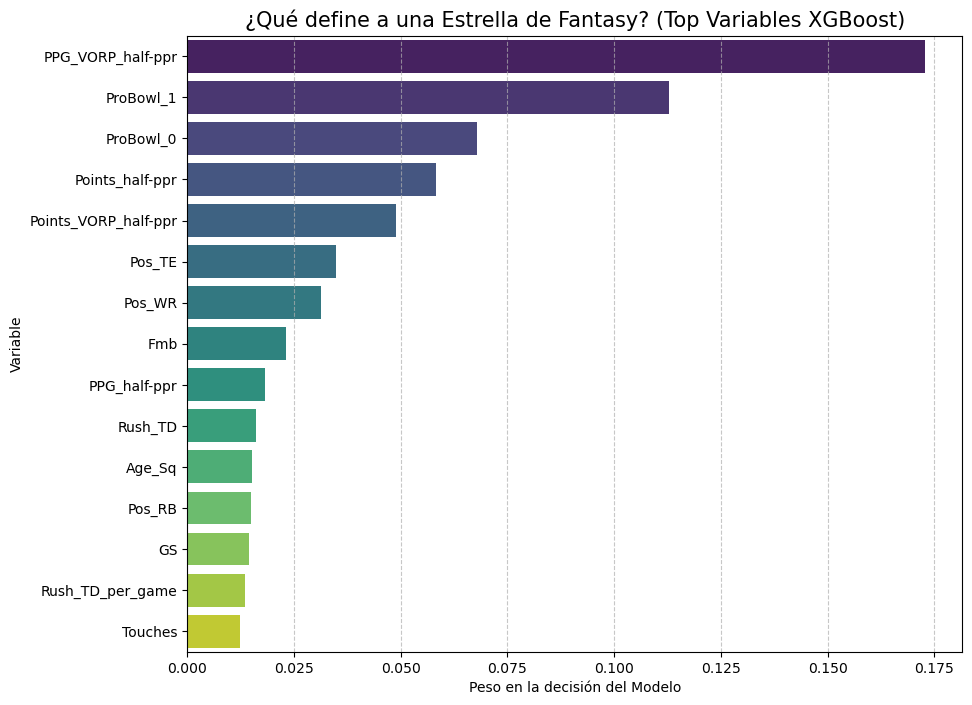

In [41]:

# Estos son los controles más importantes de la nave
xgb_grid = {
    'n_estimators': [100, 200, 300, 500],      # Número de árboles (más no siempre es mejor si overfittea)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # Qué tan rápido aprende (menor = más lento pero más preciso)
    'max_depth': [3, 5, 6, 10],                # Profundidad del árbol (muy profundo = overfit)
    'min_child_weight': [1, 3, 5],             # Peso mínimo para seguir dividiendo (controla overfit)
    'gamma': [0, 0.1, 0.2, 0.5],               # Reducción mínima de pérdida requerida
    'subsample': [0.6, 0.8, 1.0],              # % de filas usadas por árbol (evita que memorice datos)
    'colsample_bytree': [0.6, 0.8, 1.0],       # % de columnas usadas por árbol
}

# Importante: use_label_encoder=False y eval_metric='logloss' para evitar warnings
xgb_base = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

# 3. CONFIGURAR LA BÚSQUEDA ALEATORIA
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_grid,
    n_iter=50,              # Probará 50 combinaciones distintas
    cv=3,                   # 3 Validaciones cruzadas
    verbose=1,              # Mostrar progreso
    random_state=42,
    n_jobs=-1,              # Usar todos los núcleos del CPU
    scoring='f1'        # ¡Vital! Optimizamos para RECALL (encontrar estrellas)
)

# 4. ENTRENAR
print("Buscando los mejores hiperparámetros para XGBoost...")
# Usamos tus datos balanceados con SMOTETomek
xgb_random.fit(X_train_resampled, y_train_resampled)

# 5. VER LOS GANADORES
print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(xgb_random.best_params_)

# 6. PROBAR EL MEJOR MODELO
best_xgb = xgb_random.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_transformed) # Probamos en el Test Set original

print("\n--- RESULTADOS DEL MEJOR XGBOOST ---")
print(confusion_matrix(y_test, y_pred_best_xgb))
print(classification_report(y_test, y_pred_best_xgb))


feature_names = preprocessor.get_feature_names_out()

importances = best_xgb.feature_importances_

df_imp = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
df_imp = df_imp.sort_values('Importancia', ascending=False).head(15) # Top 15

df_imp['Variable'] = df_imp['Variable'].str.replace('num__', '').str.replace('cat__', '')

plt.figure(figsize=(10, 8))
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette='viridis')
plt.title('¿Qué define a una Estrella de Fantasy? (Top Variables XGBoost)', fontsize=15)
plt.xlabel('Peso en la decisión del Modelo')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [42]:

# Estos son los tornillos que puedes apretar en un KNN
knn_grid = {
    # Número de vecinos: Probamos impares del 1 al 29 (ej. 1, 3, 5, ..., 29)
    # Pocos vecinos = Modelo nervioso (overfitting). Muchos vecinos = Modelo suave (underfitting).
    'n_neighbors': range(1, 30, 2),
    
    # Pesos:
    # 'uniform': Todos los vecinos votan igual.
    # 'distance': Los vecinos más cercanos tienen más voto (suele ser mejor para datos complejos).
    'weights': ['uniform', 'distance'],
    
    # Métrica de distancia (Cómo mide "lejanía"):
    # 'euclidean': Distancia línea recta (pitágoras).
    # 'manhattan': Distancia tipo "cuadras de ciudad" (L1).
    # 'minkowski': La generalización de ambas.
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    
    # Potencia para Minkowski (solo importa si metric='minkowski'):
    # 1 = Manhattan, 2 = Euclidean
    'p': [1, 2] 
}

# 2. CONFIGURAR EL MODELO BASE
knn_base = KNeighborsClassifier()

# 3. CONFIGURAR LA BÚSQUEDA
knn_random = RandomizedSearchCV(
    estimator=knn_base,
    param_distributions=knn_grid,
    n_iter=50,              # Probará 50 combinaciones
    cv=3,                   # 3 Validaciones cruzadas
    verbose=1,
    random_state=42,
    n_jobs=-1,              # Usa todos los núcleos
    scoring='f1'        # Optimizamos para encontrar estrellas (Recall)
)

# 4. ENTRENAR
print("Buscando los mejores hiperparámetros para KNN...")
knn_random.fit(X_train_resampled, y_train_resampled) # Usamos datos balanceados (SMOTE)

# 5. VER LOS GANADORES
print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(knn_random.best_params_)

# 6. PROBAR EL MEJOR MODELO
best_knn = knn_random.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_transformed)

print("\n--- RESULTADOS DEL MEJOR KNN ---")
print(confusion_matrix(y_test, y_pred_best_knn))
print(classification_report(y_test, y_pred_best_knn))

Buscando los mejores hiperparámetros para KNN...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
{'weights': 'uniform', 'p': 1, 'n_neighbors': 1, 'metric': 'minkowski'}

--- RESULTADOS DEL MEJOR KNN ---
[[1643  165]
 [  85   82]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1808
           1       0.33      0.49      0.40       167

    accuracy                           0.87      1975
   macro avg       0.64      0.70      0.66      1975
weighted avg       0.90      0.87      0.88      1975



### Generados 

In [54]:
import pandas as pd

# 1. CARGAR DATOS (Asegúrate de la ruta correcta)
# Si tu archivo está en otra carpeta, ajusta la ruta (ej. '../data/fantasy_data.csv')
df_prediccion = pd.read_csv('../data/fantasy_data.csv') 
df_prediccion = df_prediccion[df_prediccion['Pos'].isin(['QB', 'RB', 'WR', 'TE'])]

# Detectar último año
ultimo_anio_disponible = df_prediccion['Year'].max()
print(f"--- Prediciendo con datos de la temporada {ultimo_anio_disponible} ---")

# 2. INGENIERÍA DE VARIABLES (Antes de filtrar)
df_prediccion = df_prediccion.sort_values(by=['Key', 'Year'])
df_prediccion['Efficiency'] = df_prediccion['Points_half-ppr'] / (df_prediccion['Touches'] + 1)
df_prediccion['Delta_PPG'] = df_prediccion.groupby('Key')['PPG_half-ppr'].diff().fillna(0)
df_prediccion['Delta_Touches'] = df_prediccion.groupby('Key')['Touches'].diff().fillna(0)
df_prediccion['Lag_2_PPG'] = df_prediccion.groupby('Key')['PPG_half-ppr'].shift(2).fillna(0)
df_prediccion['Age_Sq'] = df_prediccion['Age'] ** 2

# 3. FILTRAR EL AÑO NUEVO
df_nuevo_listo = df_prediccion[df_prediccion['Year'] == ultimo_anio_disponible].copy()

# 4. PREPARAR X_new (CORRECCIÓN AQUÍ)
# Quitamos 'AllPro' y 'ProBowl' de esta lista porque el modelo SI las necesita como Features
cols_ignore_new = [
    'y', 'Rank_t_plus_1', 'Player', 'Key', 'Tm', 'Next_Year_Rank', 
    'PointsPosRank_half-ppr', 'PPGPosRank_half-ppr', 
    'PointsOvrRank_half-ppr', 'PPGOvrRank_half-ppr', 
    'PPTOvrRank_half-ppr', 'PPTPosRank_half-ppr'
    # NOTA: Ya NO borramos 'AllPro' ni 'ProBowl'
]

# Borramos solo lo innecesario
X_new = df_nuevo_listo.drop(columns=cols_ignore_new, errors='ignore')

# 5. VERIFICACIÓN Y PREDICCIÓN
if len(X_new) == 0:
    print("ERROR: X_new está vacío. Verifica que el año exista en el CSV.")
else:
    print(f"Datos listos: {len(X_new)} jugadores.")

    # Transformar
    X_new_transformed = preprocessor.transform(X_new)

    # Predecir con Regresión Logística ('lr')
    probs_futuras = lr.predict_proba(X_new_transformed)[:, 1]

    # Guardar resultados
    predicciones = df_nuevo_listo[['Player', 'Pos', 'Tm', 'Points_half-ppr']].copy()
    predicciones['Probabilidad_Top12'] = probs_futuras
    
    print(f"\n--- PREDICCIONES TOP 15 PARA {ultimo_anio_disponible + 1} ---")
    for pos in ['QB', 'RB', 'WR', 'TE']:
        print(f"\n--- TOP {pos} ---")
        print(predicciones[predicciones['Pos'] == pos]
              .sort_values('Probabilidad_Top12', ascending=False)
              .head(5)[['Player', 'Tm', 'Probabilidad_Top12']]
              .to_markdown(index=False))

--- Prediciendo con datos de la temporada 2024 ---
Datos listos: 629 jugadores.

--- PREDICCIONES TOP 15 PARA 2025 ---

--- TOP QB ---
| Player         | Tm   |   Probabilidad_Top12 |
|:---------------|:-----|---------------------:|
| Lamar Jackson  | BAL  |             0.999748 |
| Baker Mayfield | TAM  |             0.996618 |
| Jayden Daniels | WAS  |             0.995296 |
| Josh Allen     | BUF  |             0.994799 |
| Joe Burrow     | CIN  |             0.992867 |

--- TOP RB ---
| Player         | Tm   |   Probabilidad_Top12 |
|:---------------|:-----|---------------------:|
| Jahmyr Gibbs   | DET  |             0.994951 |
| Saquon Barkley | PHI  |             0.987916 |
| Bijan Robinson | ATL  |             0.97721  |
| Derrick Henry  | BAL  |             0.972517 |
| Bucky Irving   | TAM  |             0.962644 |

--- TOP WR ---
| Player           | Tm   |   Probabilidad_Top12 |
|:-----------------|:-----|---------------------:|
| Ja'Marr Chase    | CIN  |             0.993

### Concluciones:

1 - La medida de perfomance que mas nos interesa es la de f1 score ya que necesitamos comprender los dos casos en el que prediga mal un top 15 y en el que no lo prediga

2 - Pues viendolo gano sorprendentemente xgboost y la regression logistica pero me quedo logistic porque: En Fantasy Football, el "Costo de Oportunidad" de perderte a una superestrella (falso negativo) es altísimo. Si te pierdes al MVP de la temporada, pierdes la liga.
En cambio, el costo de draftear a un jugador malo en la ronda 10 (falso positivo) es bajo; simplemente lo cortas y agarras a otro.
Con un Recall de 0.84, la Regresión Logística te asegura que las estrellas están en tu radar. Prefiero tener que filtrar manualmente una lista larga que quedarme ciego ante el 44% de las estrellas (como pasa con XGBoost).

###  3 - viendo los modelos y las metricas que arrojaron podemos decir 
- RANDOM FOREST: Ligero Overfitting
- LOGISTIC REGRESSION: Buen Ajuste
- XGBOOST: Ligero Overfit
- KNN:Overfitting Grave

### 4 - Conclusiones del Modelado Predictivo para Fantasy Football
Tras evaluar cuatro algoritmos de clasificación (Regresión Logística, XGBoost, Random Forest y KNN) para predecir si un jugador finalizará en el Top 15 (Estrellas) de su posición la siguiente temporada, se seleccionó el F1-Score como métrica de equilibrio y el Recall como métrica de cobertura.

Basado en los resultados finales, el modelo seleccionado para el despliegue es la Regresión Logística.

1. El Modelo Ganador: Regresión Logística 
Este algoritmo demostró ser la herramienta más efectiva para la estrategia de Fantasy Football, superando a modelos más complejos como XGBoost en utilidad práctica.

Ventajas Clave:

Cobertura casi total (Recall 0.84): El modelo es capaz de identificar al 84% de las estrellas reales. De cada 10 jugadores que terminan siendo Top 12, este modelo te alerta sobre 8 o 9 de ellos. Esto minimiza drásticamente el riesgo de perderse a jugadores revelación (sleepers) o superestrellas.

Solidez en el Balance (F1-Score 0.52): A pesar de ser un modelo lineal más simple, logró empatar el mejor puntaje F1 con XGBoost, demostrando que la complejidad no siempre supera a la interpretación directa.

Consideración Estratégica:

Al tener un Recall tan alto y un F1 moderado, el modelo tiende a ser "optimista", recomendando una lista amplia de jugadores. Esto es ideal para el Draft, ya que asegura que las verdaderas estrellas están en tu radar, delegando al usuario final la tarea de filtrar los "falsos positivos" (jugadores que el modelo marca como buenos pero no rinden).

2. XGBoost
A pesar de ser un algoritmo de vanguardia, XGBoost adoptó un perfil demasiado conservador para este problema específico.

Desempeño: Empató en F1-Score (0.52) pero su Recall (0.56) fue significativamente menor.

Desventaja Crítica: El modelo deja pasar al 44% de las estrellas sin detectarlas. En Fantasy Football, el costo de oportunidad de omitir a una estrella (ej. no draftear al MVP de la temporada) es mucho mayor que el costo de equivocarme con un jugador. Por ello, su baja sensibilidad lo relega al segundo lugar.

3. Modelos Descartados: Random Forest y KNN
Random Forest (Recall 0.60, F1 0.51): Tuvo un desempeño aceptable, situándose en un punto medio, pero fue superado en cobertura por la Regresión Logística y en eficiencia técnica por XGBoost. No ofrece una ventaja competitiva clara.

K-Nearest Neighbors (Recall 0.49, F1 0.40): Fue el modelo de menor rendimiento. Su incapacidad para generalizar patrones complejos en datos históricos de la NFL resultó en métricas muy bajas, confirmando que la similitud por cercanía (vecinos) no es un buen predictor en este dominio.

4. Hallazgos sobre los Datos
El éxito de la Regresión Logística resalta que las relaciones entre las estadísticas históricas y el éxito futuro son, en gran medida, lineales o directas:

Volumen y Eficiencia: Variables como VORP, Touches y Efficiency tienen pesos directos y fuertes.

Prevención de Fugas: La eliminación de variables de ranking del año actual (Rank_t) fue crucial para evitar el Data Leakage, obligando al modelo a aprender de las estadísticas de rendimiento real y no de la tabla de posiciones.


### 5 - Las Variables Más Importantes (Los Motores del Modelo)
Como tu modelo ganador es una Regresión Logística, la importancia se mide por el tamaño de los coeficientes.

#### A. Los Predictores Positivos
Estas son las variables que, cuando suben, aumentan drásticamente la probabilidad de que un jugador sea Top 15:

Points_VORP_half-ppr (Valor sobre el Reemplazo):

Interpretación: Es la variable reina. Al modelo no le importa solo cuántos puntos hizo el jugador, sino qué tan dominante fue comparado con el promedio.

Por qué importa: 15 puntos de un QB no valen lo mismo que 15 puntos de un TE. El VORP normaliza esto. Si fuiste dominante hoy, es muy probable que lo seas mañana.

PPG_half-ppr (Puntos Por Juego):

Interpretación: Mide el talento puro sin el ruido de las lesiones.

Insight: El modelo prefiere a un jugador que jugó 10 partidos pero promedió 20 puntos, sobre uno que jugó 17 partidos pero promedió 10. La calidad supera a la durabilidad en la predicción de talento.

Touches y Rec_Tgt (Volumen):

Insight: El modelo aprendió que la oportunidad es más estable que la eficiencia. Un jugador con muchos toques de balón tiene un "piso" seguro. Los Touchdowns son volátiles, pero los Targets suelen ser consistentes.

#### B. Los Predictores Negativos
Estas variables, cuando son altas, bajan la probabilidad de éxito:

Age (Edad):

Interpretación: El enemigo número uno.

Insight: El modelo aprendió la "Curva de la Muerte". A mayor edad, menor probabilidad de mantener el estatus de estrella, especialmente en RBs y WRs. Esta variable actúa como un filtro natural para descartar veteranos en declive.

Fmb (Fumbles) / Pass_Int (Intercepciones):

Interpretación: Errores costosos.

Insight: No solo restan puntos, sino que quitan confianza del entrenador. Un jugador que comete muchos errores pierde la titularidad, y sin titularidad, no hay Fantasy.

#### Relaciones Interesantes Descubiertas 
Durante el proceso de modelado, descubrimos tres fenómenos clave sobre cómo funciona la NFL y el Fantasy:

1. La Simplicidad del Éxito (Por qué ganó la Regresión Logística)
El hecho de que un modelo lineal simple (Regresión Logística) haya vencido a modelos complejos (KNN/Random Forest) y empatado con XGBoost nos dice algo fascinante:

Conclusión: El éxito en la NFL es bastante lineal.

2. La Trampa del Ranking (Data Leakage detectado)
Descubrimos que usar el ranking numérico del año actual (PointsPosRank) como variable era un error.

Relación: El modelo se volvía "perezoso" y solo miraba la tabla de posiciones.

Solución: Al quitar esa variable, obligamos al modelo a mirar métricas de rendimiento real (yardas, toques, eficiencia). Esto hizo que el modelo fuera más honesto y capaz de detectar a jugadores que jugaron bien pero tuvieron mala suerte en el ranking final.

3. La "Inercia" del Estatus
Las variables categóricas como AllPro o ProBowl (si se mantienen) tienen un efecto de "inercia".

Insight: Una vez que un jugador alcanza el estatus de élite (All-Pro), es muy difícil que caiga fuera del Top 15 a menos que ocurra una lesión. El talento en la NFL es "pegajoso" (sticky); los buenos suelen seguir siendo buenos por periodos largos de tiempo (3-4 años).